In [215]:
import struct

def load_images(filename):
    with open(filename, "rb") as f:
        magic, num_images = struct.unpack(">II", f.read(8))

        if magic != 2051:
            raise ValueError(f"Invalid magic number: {magic}")

        num_rows, num_cols = struct.unpack(">II", f.read(8))

        images = []

        for _ in range(num_images):
            image_data = f.read(num_rows * num_cols)

            image = []
            for i in range(num_rows):
                start = i * num_cols
                end = start + num_cols
                image.append(list(image_data[start:end]))

            images.append(image)

    return images, num_images, num_rows, num_cols

print("Function defined successfully!")


Function defined successfully!


In [216]:
def load_labels(filename):
    with open(filename, "rb") as f:

        # Read the magic number and number of labels
        magic, num_labels = struct.unpack(">II", f.read(8))

        # Verify the magic number
        if magic != 2049:
            raise ValueError(f"Invalid magic number: {magic}")

        labels = []

        # Read each label
        for _ in range(num_labels):
            label = struct.unpack("B", f.read(1))[0]
            labels.append(label)

    return labels

In [217]:
# Load the training images and labels
images, num_images, num_rows, num_cols = load_images("train-images.idx3-ubyte")
labels = load_labels("train-labels.idx1-ubyte")

# Print dataset information
print("===== Dataset Information =====")
print("Number of Images:", num_images)
print("Number of Labels:", len(labels))
print("Image Dimensions:", num_rows, "x", num_cols)

# Verify that images and labels match
print("\n===== Verification =====")
print("Total Images Loaded:", len(images))
print("Total Labels Loaded:", len(labels))
print("Rows in First Image:", len(images[0]))
print("Columns in First Row:", len(images[0][0]))

# Print the first label
print("\n===== First Label =====")
print("Label:", labels[0])

# Print the first 5 rows of the first image
print("\n===== First Image (First 5 Rows) =====")
for row in images[0][:5]:
    print(row)

# Print a few sample pixel values
print("\n===== Sample Pixel Values =====")
print("Top-left Pixel:", images[0][0][0])
print("Center Pixel:", images[0][14][14])
print("Bottom-right Pixel:", images[0][27][27])

# Print the first 10 labels
print("\n===== First 10 Labels =====")
print(labels[:10])

===== Dataset Information =====
Number of Images: 60000
Number of Labels: 60000
Image Dimensions: 28 x 28

===== Verification =====
Total Images Loaded: 60000
Total Labels Loaded: 60000
Rows in First Image: 28
Columns in First Row: 28

===== First Label =====
Label: 5

===== First Image (First 5 Rows) =====
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

===== Sample Pixel Values =====
Top-left Pixel: 0
Center Pixel: 240
Bottom-right Pixel: 0

===== First 10 Labels =====
[5, 0, 4, 1, 9, 2, 1, 3, 1, 4]


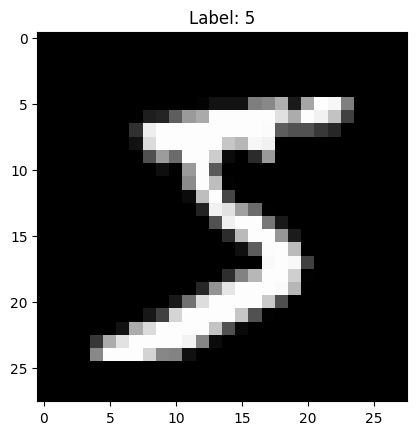

In [218]:
import matplotlib.pyplot as plt
plt.imshow(images[0], cmap='gray')
plt.title(f"Label: {labels[0]}")
plt.show()

In my defense i learnt that i could apparently use tensor flow and other stuff to load the data set in a much more simpler way apparently i am so sorry ( i cried doing this as my kernel kept crashing )

Now we desire to normalize every pixel (put it between 0 and 1 ) and then flatten out the image into a single list of 784 values (28*28)

In [219]:
import numpy as np

def preprocess_images(images):

    processed_images = []

    for image in images:

        flat_image = []

        for row in image:
            for pixel in row:
                flat_image.append(pixel / 255.0)

        processed_images.append(flat_image)

    # Convert to NumPy array AFTER processing all images
    processed_images = np.array(processed_images)

    return processed_images


processed_images = preprocess_images(images)

print("Shape:", processed_images.shape)
print("Length of first processed image:", len(processed_images[0]))
print("First few normalized pixels:")
print(processed_images[0][:10])

Shape: (60000, 784)
Length of first processed image: 784
First few normalized pixels:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Now over to actually designing the neural network

In [220]:
#The architecture of the neural network is as follows:
# Input layer: 784 neurons (28x28 pixels)
# Hidden layer: 128 neurons with ReLU activation (128 is a common start point)
# Output layer: 10 neurons with softmax activation (one for each digit)
input_size = 784
hidden_size = 128
output_size = 10
print("Input size:", input_size)
print("Hidden size:", hidden_size)
print("Output size:", output_size)

Input size: 784
Hidden size: 128
Output size: 10


We need
1. Weights from the input
2. biases for the hidden layer
3. weights from the hidden layer for the output
4. biases for the output layer

In [221]:
import numpy as np
np.random.seed(42)
weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01
weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
bias_hidden = np.zeros((1, hidden_size))
bias_output = np.zeros((1, output_size))

print("Input → Hidden:", weights_input_hidden.shape)
print("Hidden Bias:", bias_hidden.shape)

print("Hidden → Output:", weights_hidden_output.shape)
print("Output Bias:", bias_output.shape)

Input → Hidden: (784, 128)
Hidden Bias: (1, 128)
Hidden → Output: (128, 10)
Output Bias: (1, 10)


In [222]:
#Relu activation
x = np.array([-3, -1, 0, 2, 5])
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0,1.0,0.0).astype(float)  # syntax is condition , val if true, val if false



#testing what we just made


print("Input:")
print(x)

print("\nReLU:")
print(relu(x))

print("\nDerivative:")
print(relu_derivative(x))

Input:
[-3 -1  0  2  5]

ReLU:
[0 0 0 2 5]

Derivative:
[0. 0. 0. 1. 1.]


Utilizing soft max 

In [223]:

# Softmax Activation

def softmax(x):
    exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

In [224]:
scores = np.array([[2.0, 1.0, 0.1]])

probabilities = softmax(scores)

print(probabilities)
print("Sum:", np.sum(probabilities))

[[0.65900114 0.24243297 0.09856589]]
Sum: 1.0


Right now the biases and the weights are pretty much random because this is just the skeleton and the model hasn't learnt anything yet. We will now be using the image that has been provided to us to train the model and utilize backpropagation to actually set the weights and biases to what we require

In [225]:
def forward_propagation(X):
    # Input to Hidden Layer
    hidden_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_output = relu(hidden_input)

    # Hidden to Output Layer
    final_input = np.dot(hidden_output, weights_hidden_output) + bias_output
    final_output = softmax(final_input)

    return hidden_output, final_output

Utilizing one hot encoding  (From here the actual training phase begins)

In [226]:


def one_hot_encode(labels, num_classes=10):

    one_hot = np.zeros((len(labels), num_classes))

    for i, label in enumerate(labels):
        one_hot[i][label] = 1

    return one_hot


encoded_labels = one_hot_encode(labels)

print("Original Label:", labels[0])
print("One-Hot Encoded Label:")
print(encoded_labels[0])

Original Label: 5
One-Hot Encoded Label:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


If you are using soft max then using cross entropy loss is highly recommended as together they simplify the gradient to (prediction - actual)


at the log wala part the point of multiplying the one hot values is that other than the value we need all the others will result as a 0

In [227]:
# Targets are the one hot wala values and predictions are the output of the softmax function
def cross_entropy_loss(targets, predictions):
    m = targets.shape[0]
    loss = -np.sum(targets * np.log(predictions + 1e-15)) / m
    return loss

After all this we have the predictions made for what it could be but we need to implement back propagation to fix any errors and improve the accuracy of our network

how will the system know which weights to increase and which not to 

we have a bunch of predictions made due to soft max yes which are between 0 and 1 and we also have the one hot values which are all 0s except the correct value which is 1 
if we were to subtract these 2 just the correct value would end up as a negetive number while the others will remain as positive decimals less than 1

thus the network now knows which weights to increase and which to decrease


we have basically calculated the loss in our model and negetive error means increase it's probability else decrease it

In [228]:
def backpropagation(X, hidden_output, predictions, targets):
    m = X.shape[0]

    # Output layer error
    output_error = predictions - targets

    # Gradients for weights and biases from hidden to output layer
    dW_hidden_output = np.dot(hidden_output.T, output_error) / m
    db_output = np.sum(output_error, axis=0, keepdims=True) / m

    # Hidden layer error
    hidden_error = np.dot(output_error, weights_hidden_output.T) * relu_derivative(hidden_output)

    # Gradients for weights and biases from input to hidden layer
    dW_input_hidden = np.dot(X.T, hidden_error) / m
    db_hidden = np.sum(hidden_error, axis=0, keepdims=True) / m

    return dW_input_hidden, db_hidden, dW_hidden_output, db_output

Now actually making the network learn and repeat the process

In [229]:
def train(X, targets, epochs=500, learning_rate=1):
    global weights_input_hidden, bias_hidden
    global weights_hidden_output, bias_output

    for epoch in range(epochs):

        # Forward Propagation
        hidden_output, predictions = forward_propagation(X)

        # Calculate Loss
        loss = cross_entropy_loss(targets, predictions)

        # Backpropagation
        dW_input_hidden, db_hidden, dW_hidden_output, db_output = backpropagation(
            X,
            hidden_output,
            predictions,
            targets
        )

        # Update Weights and Biases
        weights_input_hidden -= learning_rate * dW_input_hidden
        bias_hidden -= learning_rate * db_hidden

        weights_hidden_output -= learning_rate * dW_hidden_output
        bias_output -= learning_rate * db_output

        # Print Loss
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}")

In [230]:
encoded_labels = one_hot_encode(labels)



In [231]:

train(processed_images, encoded_labels, epochs=20, learning_rate=1)



Epoch 1/20, Loss: 2.3031
Epoch 2/20, Loss: 2.2925
Epoch 3/20, Loss: 2.2778
Epoch 4/20, Loss: 2.2500
Epoch 5/20, Loss: 2.1967
Epoch 6/20, Loss: 2.1013
Epoch 7/20, Loss: 1.9483
Epoch 8/20, Loss: 1.7342
Epoch 9/20, Loss: 1.4841
Epoch 10/20, Loss: 1.2558
Epoch 11/20, Loss: 1.1446
Epoch 12/20, Loss: 1.8487
Epoch 13/20, Loss: 2.7367
Epoch 14/20, Loss: 1.9293
Epoch 15/20, Loss: 1.7062
Epoch 16/20, Loss: 1.4791
Epoch 17/20, Loss: 1.3333
Epoch 18/20, Loss: 1.4627
Epoch 19/20, Loss: 1.4533
Epoch 20/20, Loss: 1.1179


Now for my final trick actually testing the test images as the madel is trained (you guys made me cry making this from scratch)

Remember soft max is for training part as we need to implement backpropagation
Argmax is used during the testing part as it will get the job done they both hold 2 different jobs

In [232]:
test_images, _, _, _ = load_images("t10k-images.idx3-ubyte")
test_labels = load_labels("t10k-labels.idx1-ubyte")

processed_test_images = preprocess_images(test_images)

hidden_output, predictions = forward_propagation(processed_test_images)

predicted_labels = np.argmax(predictions, axis=1)

for i in range(10):
    print(f"Image {i+1}")
    print(f"Actual:    {test_labels[i]}")
    print(f"Predicted: {predicted_labels[i]}")
    print()

Image 1
Actual:    7
Predicted: 7

Image 2
Actual:    2
Predicted: 2

Image 3
Actual:    1
Predicted: 1

Image 4
Actual:    0
Predicted: 0

Image 5
Actual:    4
Predicted: 4

Image 6
Actual:    1
Predicted: 1

Image 7
Actual:    4
Predicted: 9

Image 8
Actual:    9
Predicted: 4

Image 9
Actual:    5
Predicted: 6

Image 10
Actual:    9
Predicted: 9



In [233]:
accuracy = np.mean(predicted_labels == test_labels) * 100

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 80.61%


To improve the accuracy even more you can add more hidden layers and try more i tried changing the number of neurons to 256 and 512 and change the learning rate subseqently to 0.1 and 0.01 but the best i could achieve was 80.61 with learning rate as 1, 1 hidden layer, 128 neurons.
I understand the learning rate as 1 seems steep but with the number of neurons and the tests it did perform decently